## Create a model to predict IC50 or whatever... regression output.

#BEFORE YOU START:

Save your own copy of this page in your drive: Click File and choose "save in drive"

In [ ]:
import pandas as pd
data = pd.read_csv("https://raw.githubusercontent.com/valeriesutanta/pcol3911/refs/heads/main/organophosphate_fp.csv")

In [ ]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.datasets import make_regression
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import scale
import matplotlib.pyplot as plt
from sklearn import set_config

In [ ]:
# Have a look at our data
data.head(2)

,0,1,2,3,4,5,6,7,8,9,...,2039,2040,2041,2042,2043,2044,2045,2046,2047,Expr
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,2.34
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,2.69


In [ ]:
# We can look at the output of data.iloc to make sure we are getting the right values in our x and y dataframes.
# Note the fist coordinates (that go into iloc) are rows and the second set are columns
data.iloc[:1,:1024]

,0,1,2,3,4,5,6,7,8,9,...,1014,1015,1016,1017,1018,1019,1020,1021,1022,1023
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [ ]:
#Load data from pandas dataframe
X = data.iloc[:,:1024]
y = data['Expr'].values

In [ ]:
y.shape # shape shows that it is a single column with 114 values

(278,)

In [ ]:
#Use randomForestRegressor to generate regression model
# Note the train_test_split function is creating a 15% test set. RandomState is set to an integer value
#the code creates the same split each time and the results don't change.
import numpy as np
xtrain, xtest, ytrain, ytest = train_test_split(X, y, test_size=.15, random_state=42)

#Click below for SKLearn Docs.
#https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.RandomForestRegressor.html

rfr = RandomForestRegressor(random_state=42)
rfr.fit(xtrain, ytrain)

ypred_train = rfr.predict(xtrain)

print("Training Scores")
print("_______________")
correlation = np.corrcoef(ypred_train, ytrain)[0,1]
print("Correlation:", correlation)
score = rfr.score(xtrain, ytrain)
print("R-squared:", score)
mse = mean_squared_error(ytrain, ypred_train)
print("MSE: ", mse)
print("RMSE: ", mse**(1/2.0))

Training Scores
_______________
Correlation: 0.9843557906555961
R-squared: 0.9661928914837171
MSE:  0.09268865715173502
RMSE:  0.3044481189820936


# **Rules of Thumb for model performance**

**R-Square**

*Training*

A good R² is typically ≥ 0.7 for QSAR models, indicating that the model explains 70% or more of the variance in the data.

An R² > 0.9 suggests an excellent fit, but beware of overfitting, especially if the test set performance is much lower.

*Testing*

A test R² of ≥ 0.5 is often considered acceptable, particularly for biological datasets that tend to have inherent variability.

For high-quality QSAR models, an R² of 0.6–0.8 is desirable.

**RMSE**

RMSE should ideally be as low as possible, but what qualifies as "low" depends on the scale of the response variable.
Compare RMSE to the range of the observed values or the standard deviation of the response variable:
An RMSE less than 10%–15% of the range of the target variable is generally acceptable.
Alternatively, RMSE that is lower than the standard deviation of the target variable indicates reasonable performance.

RMSE for training and test sets should be similar to ensure no overfitting.

### Now to assess the predictive performance of the model on the hold-out test set

In [ ]:
import numpy as np

x = ytest # The ytest values
y = rfr.predict(xtest) # The predicted y values for the holdout test set X values.
a, b = np.polyfit(x, y, 1)

print("Test Scores")
print("_______________")
correlation = np.corrcoef(x, y)[0,1]
print("Correlation:", correlation)
rsquare = correlation**2
print("Testset Rsquare:", rsquare)
mse = mean_squared_error(ytest, y)
print("MSE: ", mse)
print("RMSE: ", mse**(1/2.0))

Test Scores
_______________
Correlation: 0.8754023331865733
Testset Rsquare: 0.7663292449484964
MSE:  0.6016902204439172
RMSE:  0.775686934557955


In [ ]:
#Find axis dimensions for scatter plot
import math
max_dim = math.ceil(max(x.max(),y.max())) +1
min_dim = math.floor(min(x.min(), y.min())) -1

Text(0, 0.5, 'Predicted AChE Binding Values')

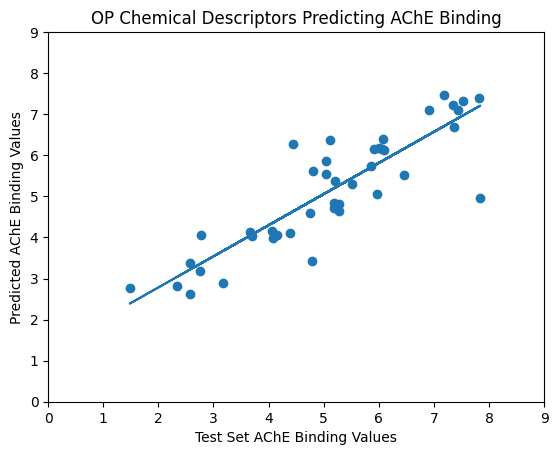

In [ ]:
plt.scatter(x, y)
plt.ylim([min_dim, max_dim])
plt.xlim([min_dim, max_dim])
plt.plot(x, a*x+b)
plt.title("OP Chemical Descriptors Predicting AChE Binding")
plt.xlabel('Test Set AChE Binding Values')
plt.ylabel('Predicted AChE Binding Values')

## Finally, you can save the model for future use if you like.
Don't forget to download the ".pkl" file.

In [ ]:
# Finally we should save the model for future use.
# This example saves the models called "rfr" used in the demo above.
# We can generate several models by changing the random forest parameters and see which is best.
import joblib
joblib.dump(rfr, 'first_rfr.pkl')

['first_rfr.pkl']

## The code below demonstrates loading the saved model to use on a fresh prospective dataset.

In [ ]:
#later you can load the model and predict on a completely new dataset.
#Load model from .pkl file
import joblib

RFR_predictor = joblib.load('first_rfr.pkl')

# Here we would have a csv file containing only the 1024 (or 2048) fingerprint values,
# But we don't know the Expr values for them so X_hold_out = the whole file.

X_hold_out = pd.read_csv("path_to_csv_file")

# Predict data set using loaded model
New_pred = RFR_predictor.predict(X_hold_out)

FileNotFoundError: [Errno 2] No such file or directory: 'path_to_csv_file'


**Prospective data is hard to get and we often use a hold-out dataset that was not used in development of the model for the purpose of final model performance assessment. Cross validation can be used to find the best model parameters in training.**

Here is a workflow from the Scikitlearn documentation for cross validation. Note the Test Data on the right takes no part in model development and validation on the left.

https://scikit-learn.org/stable/modules/cross_validation.html


<img src="https://scikit-learn.org/stable/_images/grid_search_workflow.png" width="400">